In [46]:
import rebound
import numpy as np 
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit

In [ ]:
def heartbeat(sim_pointer):
    global v, cycle
    sim = sim_pointer.contents
    t = sim.t

    dt = boxL*nx/ncols/(2*Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
        t = 0

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity

# Ms = np.linspace(10,100,10) #Massa gas
M = 100
# ms = np.linspace(10,100,10) #Massa BH
# Vxs = np.linspace(1,100,100) #Velocità relativa
m = 100

scanname = "scandt2"
scanfolder = f"scans/{scanname}"
picklefile = f'scans/{scanname}.pickle'
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
picklefile = f'scans/{scanname}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

Vx = 10
x0 = nx*boxL/2*0.1

out = []

def line(x,a,q):
    return a*x+q

dts = np.logspace(-5,-2,19)

counter = 0
for dt in dts:
    sim = rebound.Simulation()
    sim.heartbeat = heartbeat
    sim.configure_box(boxL,nx,ny)
    sim.boundary = "open"
    sim.gravity = "tree"
    sim.integrator = "leapfrog"
    sim.softening = 0.1
    sim.opening_angle2 = 1.5
    sim.collision = "none"
    sim.dt = dt

    #Add initial particles
    xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
    ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
    for x in xs:
        for y in ys:
            vx = -2*Vx
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
    sim.add(m=m,x=x0,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
    v = []
    cycle = 0

    sim.integrate(T)

    ts = np.linspace(0,sim.t,len(v))
    cut = (ts>=0)
    popt, _ = curve_fit(line, ts[cut], v[cut])
    a = popt[0]

    title = f"dt = {dt}"

    if save_fig:
        fig, ax = plt.subplots()
        ax.plot(ts[cut],v[cut])
        ax.plot(ts[cut],line(ts[cut],*popt),'--r')
        ax.set_title(title)
        filename = f"{scanfolder}/{counter:05d}.png"
        fig.savefig(filename)
        plt.close()
    else:
        print(title)

    results = {
        "dt": dt,
        "v": v
    }

    out.append(results)
    if autosave:
        with open(picklefile, 'wb') as handle:
            pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

    counter += 1

if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

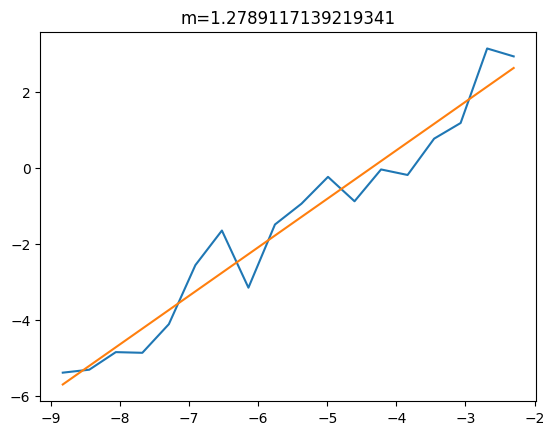

In [ ]:
scanname = "scandt"
scanfolder = f"scans/{scanname}"
picklefile = f'scans/{scanname}.pickle'

with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

dts = np.array([res["dt"] for res in out])
vs = [res["v"] for res in out]

T = 10

from scipy.interpolate import make_splrep

v0 = vs[0]
x0 = np.linspace(0,1,len(v0))*T
v0spl = make_splrep(x0,v0)

errs = []
for i in range(1,len(out)):
    v1 = vs[i]
    x1 = np.linspace(0,1,len(v1))*T
    v1spl = make_splrep(x1,v1)
    fig, ax = plt.subplots()
    dy = v0spl(x0)-v1spl(x0)
    err = np.sqrt(np.sum(dy**2))
    errs.append(err)
    ax.plot(x0,dy)
    ax.set_title(f"{dts[i]:0.4f} vs {dts[0]:0.4f}")
    if i==0:
        plt.show()
    plt.close()

errs = np.array(errs)
fig, ax = plt.subplots()
Xfit = np.log(dts[1:])
Yfit = np.log(errs)
ax.plot(Xfit,Yfit)
# ax.set_xscale("log")
# ax.set_yscale("log")
def line(x,m,q):
    return m*x+q
popt, _ = curve_fit(line,Xfit,Yfit)
ax.plot(Xfit,line(Xfit,*popt))
ax.set_title(f"m={popt[0]}")
plt.show()